# simulate_fmri/ demo

A simulated fMRI session of a digital brain, taken through the same
preprocessing and reconstruction as a real scan, and checked against the truth
at every stage.

1. **The sequences.** `sequences/` writes `scan_info.mat`: where in (ky, kz) and
   when every echo of every shot of every frame is acquired, the readout
   trajectories, and the deGRE's protocol. Default protocol: 2.4 mm,
   90 x 90 x 60, R = 10, 54 echoes per shot, volume TR 0.506 s, 60 s.
2. **The session.** `simulate_fmri.session` writes the raw readouts of all four
   scans (noise, EPIcal, deGRE, ArbEPI) of a BrainWeb phantom: a field map from
   the head's susceptibility, T2* decay, ramp-sampled readouts with a delay and
   an odd/even phase, 32 coils with correlated thermal noise, physiological
   noise, and block-design BOLD activations in the visual and motor cortices.
3. **Preprocessing.** `preprocess/` runs on those archives unchanged. What it
   calibrates and estimates is compared with what the simulation put in.
4. **Reconstruction and score.** `recon.sense` with the estimated maps, then
   `recon.testbed.score` against the truth.

`README.md` lists what is modeled, from which measurements, and what is not.
Kernel: `.venv-simulate` (see `README.md`'s setup). The whole notebook
takes 50 to 60 minutes on a 64-core machine with an RTX A6000: preprocessing 6
to 20 minutes depending on what else the CPUs are doing (ESPIRiT on 32 coils),
the B0-corrected reconstruction 40; everything else is quick.

In [1]:
%%capture
import os
import sys
import time
import warnings
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np

REPO = Path.cwd().parent if Path.cwd().name == "simulate_fmri" else Path.cwd()
os.chdir(REPO)
sys.path.insert(0, str(REPO))
warnings.simplefilter("ignore")

from params import load_params  # noqa: E402
from preprocess import utils as pre_utils  # noqa: E402
from preprocess.coils import apply_gcc_image, apply_whitening  # noqa: E402
from preprocess.preprocess import PreprocessConfig, preprocess  # noqa: E402
from recon import testbed  # noqa: E402
from recon.sense import main as recon_sense  # noqa: E402
from sample.gen_sampling_masks import resolve_omegas  # noqa: E402
from sequences.ArbEPI import generate_arbepi  # noqa: E402
from sequences.deGRE import generate_degre  # noqa: E402
from simulate_fmri.session import SessionConfig, simulate_session  # noqa: E402

OUT = "output/simulate_fmri"
NAME = "demo"

In [2]:
def show(volumes: dict, center=None, contour=None, kw=None, title=""):
    # Sagittal / coronal / axial slices through `center` (default: the middle), one row per volume
    fig, axes = plt.subplots(len(volumes), 3, figsize=(9, 2.7 * len(volumes)), squeeze=False)
    for i, (row, (name, vol)) in enumerate(zip(axes, volumes.items())):
        c = [n // 2 for n in vol.shape] if center is None else center
        opts = dict(cmap="gray", vmin=0, vmax=np.nanpercentile(vol, 99.8))
        opts.update((kw or {}).get(name, {}))
        for j, (ax, view) in enumerate(zip(row, ["sagittal", "coronal", "axial"])):
            sl = [slice(None)] * 3
            sl[j] = c[j]
            im = ax.imshow(np.rot90(vol[tuple(sl)]), **opts)
            if contour is not None and contour[tuple(sl)].any():
                ax.contour(np.rot90(contour[tuple(sl)]), levels=[0.5], colors="c", linewidths=0.6)
            ax.set_xticks([])
            ax.set_yticks([])
            if i == 0:
                ax.set_title(view)
        row[0].set_ylabel(name)
        fig.colorbar(im, ax=row[2], fraction=0.046)
    fig.suptitle(title)
    plt.show()

## 1. The sequences

`generate_arbepi` writes `scan_info.mat`; `generate_degre` adds the deGRE's
realized echo times and ADC dwell to it. (`main.py` runs both, plus the
calibration and noise sequences, which the simulation does not need.) To
simulate another protocol, edit `params.py`; to simulate a past session, point
at its `scan_info.mat`.

In [3]:
%%capture --no-stdout
params = load_params(output_dir=f"{OUT}/seq")
generate_arbepi(resolve_omegas(params), params)
generate_degre(params)
SCAN_INFO = f"{OUT}/seq/scan_info.mat"
with h5py.File(SCAN_INFO) as f:
    print({k: np.round(f[k][()].ravel(), 6).tolist() for k in
           ("fa", "adc_dwell", "TE_degre", "TR_degre", "alpha_degre", "dwell_degre")})

Selected ADC dwell: 4.0 us (fastest feasible for Nx=90, fov_x=216.0 mm -- see lib/readout_from_params.py's find_min_feasible_dwell)


Timing check passed successfully


Timing check passed successfully


{'fa': [15.882552], 'adc_dwell': [4e-06], 'TE_degre': [0.00224, 0.004476], 'TR_degre': [0.0057], 'alpha_degre': [5.361496], 'dwell_degre': [4e-06]}


## 2. The session

`SessionConfig()` is a realistic 3 T head scan; every effect has a switch
(`b0_scale=0`, `noise=0`, `physio=None`, `activation=False`, `delay=0`, ...).
The model evaluates everything spatial once per echo index, so the run's length
costs nothing.

Two regions are activated, each with its own block design (`cfg.activations`):
the visual (occipital) cortex, 10 s on and 10 s off from t = 0, and the hand
area of one hemisphere's motor cortex, the same blocks starting 5 s later.
The quarter-cycle lag makes the two time courses nearly uncorrelated, so each
region's scores are its own. `Activation('motor', onset=0)` makes them
simultaneous.

In [4]:
%%capture --no-stdout
t0 = time.time()
cfg = SessionConfig()
paths = simulate_session(SCAN_INFO, OUT, NAME, cfg=cfg)
print(f"{time.time() - t0:.0f} s")

119 frames x 10 shots x 54 echoes of 100 samples, (90, 90, 60) at (2.4, 2.4, 2.4) mm, R = 10.0; 32 coils, spins on a (180, 180, 120) grid, cuda


thermal noise: SNR of a fully sampled volume 115 (median over brain voxels)


Wrote output/simulate_fmri/scanarchives/demo_epi.h5
      output/simulate_fmri/scanarchives/demo_cal.h5
      output/simulate_fmri/scanarchives/demo_noise.h5
      output/simulate_fmri/scanarchives/gre.h5
      output/simulate_fmri/seqs/demo/scan_info.mat
      output/simulate_fmri/demo_truth.h5
28 s


What a scan would leave: four archives of raw readouts in acquisition order,
and the sequence's record.

demo_noise.h5    noise   readouts (205, 32, 100)        5 MB
demo_cal.h5      EPIcal  readouts (540, 32, 100)       14 MB
gre.h5           deGRE   readouts (7488, 32, 72)      138 MB
demo_epi.h5      ArbEPI  readouts (64260, 32, 100)     1645 MB


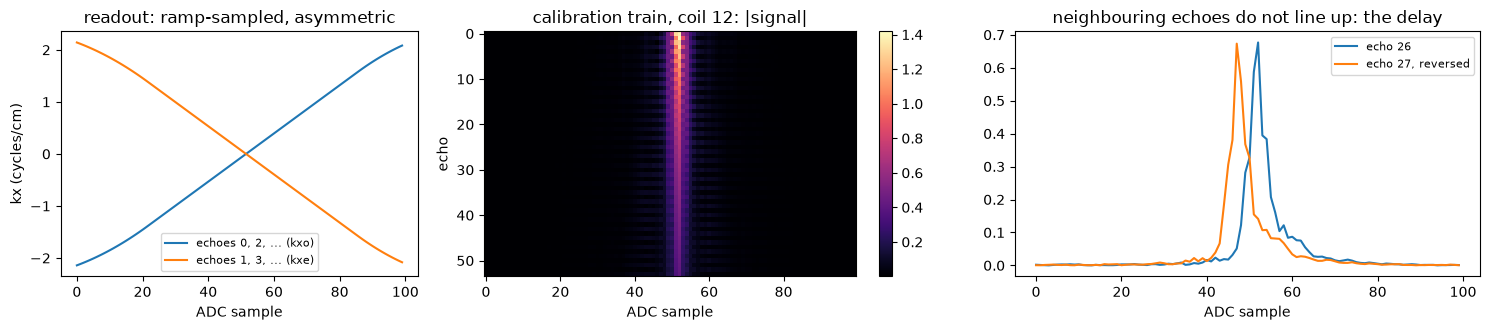

In [5]:
for key in ("noise", "cal", "gre", "epi"):
    with h5py.File(paths[key]) as f:
        d = f["readouts"]
        print(f"{Path(paths[key]).name:16s} {f.attrs['scan']:7s} readouts {d.shape}  "
              f"{os.path.getsize(paths[key]) / 1e6:7.0f} MB")

kxo, kxe = pre_utils.load_kxoe(SCAN_INFO)
with h5py.File(paths["cal"]) as f:
    train = f["readouts"][:params.ETL]  # one blip-free echo train, (ETL, Ncoils, Nfid)
coil = np.argmax(np.abs(train).sum(axis=(0, 2)))

fig, ax = plt.subplots(1, 3, figsize=(15, 3.4), width_ratios=[1, 1.3, 1.3])
ax[0].plot(kxo, label="echoes 0, 2, ... (kxo)")
ax[0].plot(kxe, label="echoes 1, 3, ... (kxe)")
ax[0].set_xlabel("ADC sample")
ax[0].set_ylabel("kx (cycles/cm)")
ax[0].set_title("readout: ramp-sampled, asymmetric")
ax[0].legend(fontsize=8)
im = ax[1].imshow(np.abs(train[:, coil]), aspect="auto", cmap="magma")
ax[1].set_xlabel("ADC sample")
ax[1].set_ylabel("echo")
ax[1].set_title(f"calibration train, coil {coil}: |signal|")
plt.colorbar(im, ax=ax[1])
ax[2].plot(np.abs(train[26, coil]), label="echo 26")
ax[2].plot(np.abs(train[27, coil])[::-1], label="echo 27, reversed")
ax[2].set_xlabel("ADC sample")
ax[2].set_title("neighbouring echoes do not line up: the delay")
ax[2].legend(fontsize=8)
plt.tight_layout()
plt.show()

The truth, on the acquisition grid: the noise-free image at TE, the field map
(what a field map of this scan could measure), and the activations' fractional
signal change with the activated voxels of each region outlined.

SNR of a fully sampled volume: 115;  field over the brain: std 28 Hz, -144 to 272 Hz
block_occipital: 614 activated voxels, median change 1.53%
block_motor: 204 activated voxels, median change 1.59%
correlation of the two time courses: -0.005


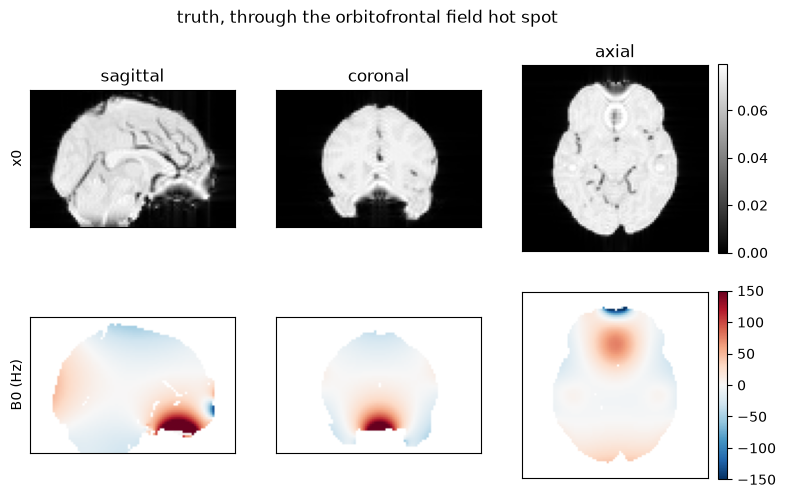

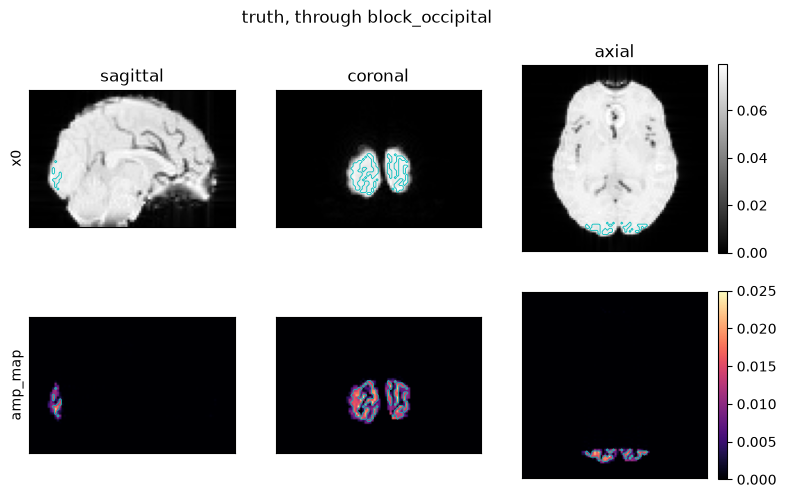

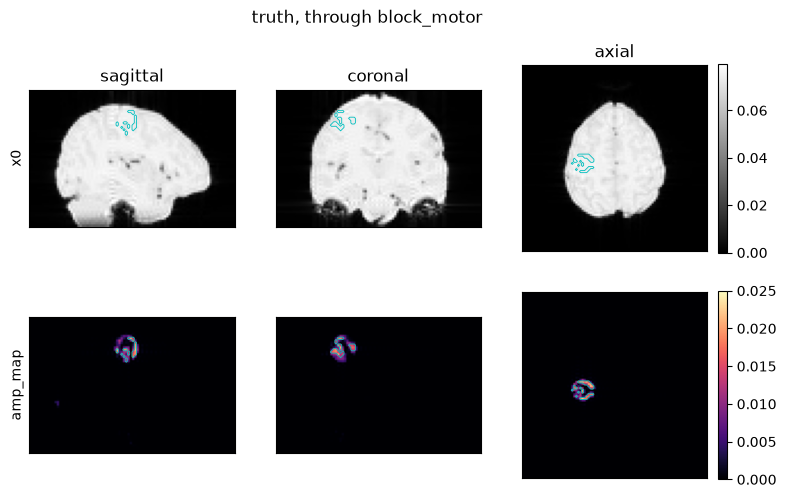

In [6]:
with h5py.File(paths["truth"]) as f:
    g = f["truth"]
    x0, b0_true, amp_map = g["x0"][()], g["b0_map"][()], g["amp_map"][()]
    rois, waves, brain = g["roi_masks"][()], g["waveforms"][()], g["brain_mask"][()]
    names = [str(n) for n in g.attrs["roi_names"]]
    smaps_true, tissues = g["smaps"][()], g["tissues"][()]
    truth = dict(g.attrs)
    oe_true = g["oe_phase"][()]
    physio = {k: g["physio"][k][()] for k in g["physio"]}
    r2s_change = g["r2s_change"][()]
    b0_true_degre = g["degre/b0_map"][()]
    volume_tr = f.attrs["volume_tr"]
print(f"SNR of a fully sampled volume: {truth['snr0']:.0f};  field over the brain: "
      f"std {b0_true[brain].std():.0f} Hz, {np.percentile(b0_true[brain], 0.1):.0f} to "
      f"{np.percentile(b0_true[brain], 99.9):.0f} Hz")
for name, roi, amp in zip(names, rois, truth["amps"]):
    print(f"{name}: {roi.sum()} activated voxels, median change {100 * amp:.2f}%")
print(f"correlation of the two time courses: {np.corrcoef(waves)[0, 1]:+.3f}")
show({"x0": x0, "B0 (Hz)": np.where(brain, b0_true, np.nan)},
     center=[45, 60, 18], contour=None,
     kw={"B0 (Hz)": dict(cmap="RdBu_r", vmin=-150, vmax=150)},
     title="truth, through the orbitofrontal field hot spot")
for name, roi in zip(names, rois):
    show({"x0": x0, "amp_map": amp_map}, center=np.round(np.argwhere(roi).mean(axis=0)).astype(int),
         contour=roi, kw={"amp_map": dict(cmap="magma", vmin=0, vmax=0.025)},
         title=f"truth, through {name}")

What changes from excitation to excitation (every 50.6 ms, ten per frame):
each activation's R2*, a breathing-induced field offset, cardiac pulsation, and
slow BOLD-like fluctuations.

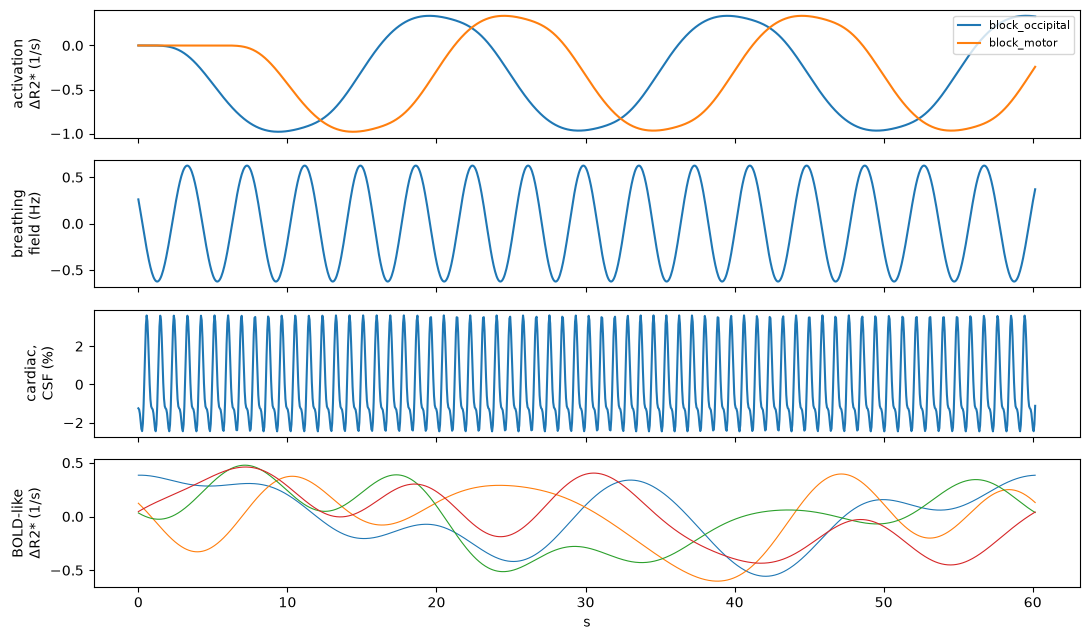

In [7]:
t_exc = np.arange(r2s_change.shape[1]) * truth["tr_shot"]
fig, ax = plt.subplots(4, 1, figsize=(11, 6.5), sharex=True)
for name, course in zip(names, r2s_change):
    ax[0].plot(t_exc, course, label=name)
ax[0].legend(fontsize=8, loc="upper right")
ax[0].set_ylabel("activation\nΔR2* (1/s)")
ax[1].plot(t_exc, physio["frequency_hz"])
ax[1].set_ylabel("breathing\nfield (Hz)")
ax[2].plot(t_exc, 100 * physio["cardiac"] * 0.02)
ax[2].set_ylabel("cardiac,\nCSF (%)")
for k in sorted(k for k in physio if k.startswith("bold_like")):
    ax[3].plot(t_exc, physio[k], lw=0.8)
ax[3].set_ylabel("BOLD-like\nΔR2* (1/s)")
ax[3].set_xlabel("s")
plt.tight_layout()
plt.show()

## 3. Preprocessing

The same call as for a scan. It whitens with the noise scan, calibrates the
readout delay and the odd/even phase on the EPIcal scan, grids the ramp-sampled
EPI readouts and places them in (ky, kz), compresses the coils with GCC fitted
on the deGRE, and estimates sensitivity maps (ESPIRiT), the B0 map
(MRIFieldmaps.jl) and R2* from the deGRE.

In [8]:
%%capture cap
t0 = time.time()
PRE = preprocess(PreprocessConfig(datdir=OUT, seqnames=[NAME]), NAME)
print(f"{(time.time() - t0) / 60:.0f} min")

Loading '/tmp/user/1015/tmpp90e_gsh/gre.h5'...


  images size (Nx, Ny, Nz, Ncoils, Nechoes): (72, 72, 51, 32, 2)
  TE_degre (s): 

Float32[0.00224, 0.004476]


  magnitude mask: 75069 / 264384 voxels above 0.1 x peak magnitude
Loading sensitivity maps from '/tmp/user/1015/tmpp90e_gsh/gre.h5'...


  combined (magnitude & ESPIRiT-eigenvalue) mask: 75025 / 264384 voxels
  dropped 0 voxels in components < 64 voxels
Unwrapping finit via ROMEO...


  finit range (Hz, masked): (-319.1049f0, 558.2905f0)
Running MRIFieldmaps.b0map (precon=diag, smap=provided)...


[ Info: ite_solve: NCG-MLS with precon diag


[ Info: 1 of 30
[ Info: 11 of 30


[ Info: 21 of 30


Wrote '/tmp/user/1015/tmpp90e_gsh/b0map.h5'.


In [9]:
log = cap.stdout.splitlines()  # noqa: F821 -- set by %%capture above
print("\n".join(line for line in log if not line.startswith("  frame ")))

=== demo ===
Stage A: calibration
  readout delay (k-space center offset): -0.30 samples, calibrated
  odd/even phase at mid-train: constant -0.3004 rad, linear 0.0083 rad/FOV; first to last echo pair: -0.0749 rad, +0.0341 rad/FOV
Stage A: gridding frames 1-119 (540 shots each)
  GCC: lowest per-x energy kept [0.6871 0.6882 0.6883] at x = [ 2 88 86]
Coil compression (GCC): 32 -> 19 virtual coils (energy; 99.90% of energy kept)
Sensitivity maps (ESPIRiT)...
B0 field map (MRIFieldmaps.jl)...
Calibration region: ky 39:52, kz 26:35
Stage B: writing output/simulate_fmri/recon/demo_preprocessed.h5
  thermal-noise variance of the output k-space: 0.9514
Done: output/simulate_fmri/recon/demo_preprocessed.h5
18 min


What preprocessing found, against what the simulation put in.

In [10]:
with h5py.File(PRE) as f:
    a = dict(f.attrs)
    oe = np.asarray(a["oephase_a"]).reshape(-1, 2)
    sweep = {k: f["delay_sweep"][k][()] for k in f["delay_sweep"]}
    smaps, W, GCC = f["smaps"][()], f["W"][()], f["GCC"][()]
    b0_est, b0_mask, r2s_est = f["b0_map"][()], f["b0_mask"][()] > 0, f["r2star_map"][()]
    b0_est_degre, mask_degre = f["degre/b0_map"][()], f["degre/mask"][()] > 0

# sensitivity maps: the true ones, taken through the same whitening and compression
st = apply_gcc_image(apply_whitening(smaps_true, W), GCC)
num = np.abs((smaps.conj() * st).sum(-1))
den = np.sqrt((np.abs(smaps) ** 2).sum(-1) * (np.abs(st) ** 2).sum(-1))
agree = np.divide(num, den, out=np.zeros_like(num), where=den > 0)
err_b0 = np.abs(b0_est_degre - b0_true_degre)[mask_degre]
gm, wm = tissues[1] > 0.9, tissues[0] > 0.9

rows = [
    ("readout delay (samples)", f"{truth['delay']:+.2f}", f"{a['delay']:+.2f}"),
    ("odd/even phase, first / last echo pair (rad)",
     f"{oe_true[0, 0]:+.3f} / {oe_true[-1, 0]:+.3f}", f"{oe[0, 0]:+.3f} / {oe[-1, 0]:+.3f}"),
    ("noise variance after whitening", "1", f"{a['noise_var']:.2f}"),
    ("coils", f"{a['Ncoils']}", f"{a['Nc_out']} virtual"),
    ("sensitivity maps: agreement per brain voxel, median", "1", f"{np.median(agree[brain]):.4f}"),
    ("B0 map, deGRE grid: |error| median / 90th pct (Hz)",
     f"field std {b0_true_degre[mask_degre].std():.0f}",
     f"{np.median(err_b0):.1f} / {np.percentile(err_b0, 90):.1f}"),
    ("R2* in gray / white matter (1/s)", "16.8 / 18.3",
     f"{np.median(r2s_est[gm]):.1f} / {np.median(r2s_est[wm]):.1f}"),
]
print(f"{'':52s} {'simulated':>16s} {'preprocess':>16s}")
for name, sim, pre in rows:
    print(f"{name:52s} {sim:>16s} {pre:>16s}")

                                                            simulated       preprocess
readout delay (samples)                                         -0.30            -0.30
odd/even phase, first / last echo pair (rad)          -0.250 / -0.320  -0.263 / -0.338
noise variance after whitening                                      1             0.95
coils                                                              32       19 virtual
sensitivity maps: agreement per brain voxel, median                 1           0.9979
B0 map, deGRE grid: |error| median / 90th pct (Hz)       field std 30        0.3 / 3.6
R2* in gray / white matter (1/s)                          16.8 / 18.3      16.2 / 18.1


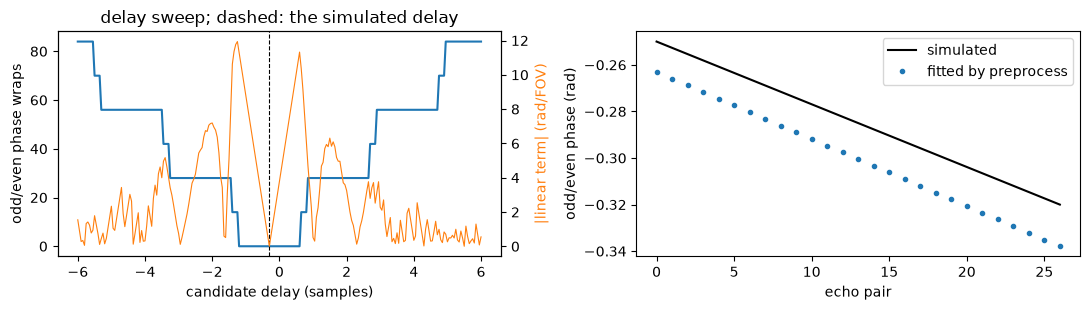

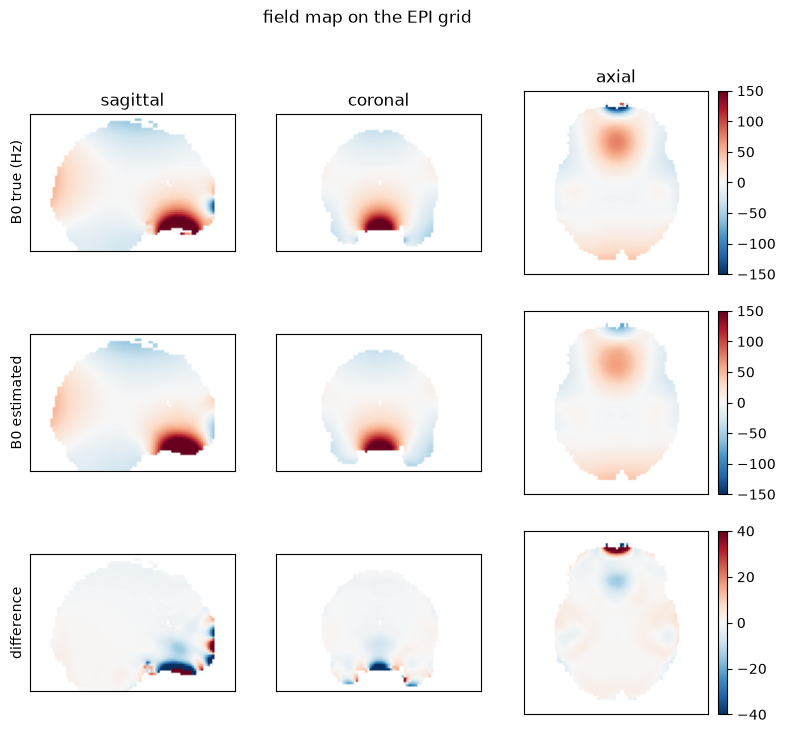

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].plot(sweep["delay"], sweep["wrap_count"], label="phase wraps")
ax[0].set_xlabel("candidate delay (samples)")
ax[0].set_ylabel("odd/even phase wraps")
ax2 = ax[0].twinx()
ax2.plot(sweep["delay"], np.abs(sweep["a2"]), "C1", lw=0.8)
ax2.set_ylabel("|linear term| (rad/FOV)", color="C1")
ax[0].axvline(truth["delay"], color="k", ls="--", lw=0.8)
ax[0].set_title("delay sweep; dashed: the simulated delay")
pair = np.arange(len(oe))
ax[1].plot(pair, oe_true[:, 0], "k", label="simulated")
ax[1].plot(pair, oe[:, 0], "C0o", ms=3, label="fitted by preprocess")
ax[1].set_xlabel("echo pair")
ax[1].set_ylabel("odd/even phase (rad)")
ax[1].legend()
plt.tight_layout()
plt.show()

show({"B0 true (Hz)": np.where(b0_mask, b0_true, np.nan),
      "B0 estimated": np.where(b0_mask, b0_est, np.nan),
      "difference": np.where(b0_mask, b0_est - b0_true, np.nan)},
     center=[45, 60, 18],
     kw={"B0 true (Hz)": dict(cmap="RdBu_r", vmin=-150, vmax=150),
         "B0 estimated": dict(cmap="RdBu_r", vmin=-150, vmax=150),
         "difference": dict(cmap="RdBu_r", vmin=-40, vmax=40)},
     title="field map on the EPI grid")

## 4. Reconstruction and score

Iterative SENSE with the L1-wavelet + TV regularizer and the temporal
high-pass penalty, as one would run it on a scan: once ignoring the field, once
with the estimated B0 map. The volume TR is passed by hand, as for a scan
(`preprocess/` does not record it).

The B0 operator's norm `sigma1A` normally comes from a power iteration, which
on this session took 75 minutes on a shared GPU and returned 1.488; it is
passed here to skip that. Leave it out after changing anything that changes the
operator (protocol, coils, field).

In [12]:
%%capture --no-stdout
RECONS = {}
for label, kw in (("no B0", dict(sigma1A=1.0)), ("B0", dict(B0=True, sigma1A=1.49))):
    t0 = time.time()
    out = recon_sense(OUT, NAME, "wavelet-tv", hp_weight=3.0, volume_tr_s=float(volume_tr),
                      niters=100, tag="hp3", **kw)
    RECONS[label] = out + ".h5"
    print(f"{label}: {(time.time() - t0) / 60:.0f} min")

Loading sensitivity maps...
  Sensitivity maps: (90, 90, 60, 19)
Acceleration factor R ~ 10.00
Building encoding operator...
  temporal high-pass penalty: mu=3.0, cutoff 0.15 Hz, TR 0.5060 s: 19 of 119 DCT components left unpenalized
Loading k-space (gathered per frame, never materializing the dense array)...


  thermal-noise variance 0.9514 (recorded by preprocessing) -- dividing k-space by 0.9754
  VRAM free after loading gathered k-space: 45.52 / 50.90 GB

Reconstructing 119 frames jointly with L1-wavelet + TV (lamb_l1=0.005, lamb_tv=0.005, lamb_ttv=0.0, hp_weight=3.0), 100 PDHG iterations, operator normalized by 1/1.0000...


Wall-clock: 150.0s (1.3s/frame)


Wrote output/simulate_fmri/recon/sense_wavelet-tv_hp3/demo_recon.h5


Wrote output/simulate_fmri/recon/sense_wavelet-tv_hp3/demo_recon.nii.gz + .json
no B0: 3 min
Loading sensitivity maps...
  Sensitivity maps: (90, 90, 60, 19)
Acceleration factor R ~ 10.00
Building encoding operator...
  Loading B0 field map from output/simulate_fmri/recon/demo_preprocessed.h5 (L=32, nbins=128)...
  b0_map: clipped 970 voxel(s) to its 0.1-99.9 percentile range [-92, 214] Hz (full range [-153, 377] Hz)
  temporal high-pass penalty: mu=3.0, cutoff 0.15 Hz, TR 0.5060 s: 19 of 119 DCT components left unpenalized
Loading k-space (gathered per frame, never materializing the dense array)...


  thermal-noise variance 0.9514 (recorded by preprocessing) -- dividing k-space by 0.9754
  VRAM free after loading gathered k-space: 45.44 / 50.90 GB

Reconstructing 119 frames jointly with L1-wavelet + TV (lamb_l1=0.005, lamb_tv=0.005, lamb_ttv=0.0, hp_weight=3.0), 100 PDHG iterations, operator normalized by 1/1.4900...


Wall-clock: 2330.9s (19.6s/frame)


Wrote output/simulate_fmri/recon/sense_wavelet-tv_b0_hp3/demo_recon.h5


Wrote output/simulate_fmri/recon/sense_wavelet-tv_b0_hp3/demo_recon.nii.gz + .json
B0: 40 min


`recon.testbed.score` compares magnitudes after one global scale: the error of
the mean image and of each frame, the temporal fluctuation of voxels outside
the activation (which here includes the simulated physiological noise, so it is
not zero even for a perfect reconstruction), and for each activated region the
recovered amplitude (1 = exact), its t-score and the leakage around it. The
false-positive fractions are of the first region's regressor.

In [13]:
scores = {label: testbed.score(paths["truth"], fn) for label, fn in RECONS.items()}
print(f"{'':34s} " + " ".join(f"{label:>10s}" for label in scores))
for k in scores["B0"]:
    print(f"{k:34s} " + " ".join(f"{s[k]:10.3f}" for s in scores.values()))

                                        no B0         B0
alpha                                   0.001      0.001
object_thresh                           0.100      0.100
nrmse_mean_pct                         23.113     10.743
nrmse_frame_pct                        23.837     10.953
fluct_pct                               4.937      1.189
fluct_inband_pct                        4.742      1.158
fluct_outband_pct                       1.316      0.264
block_occipital_t_lowband              -0.048      2.283
block_occipital_amp_ratio              -0.034      0.638
block_occipital_t                      -0.120      5.930
block_occipital_corr                    0.115      0.786
block_occipital_leak_ratio             -0.079     -0.156
block_motor_t_lowband                   0.535      2.489
block_motor_amp_ratio                   0.559      0.506
block_motor_t                           1.388      6.365
block_motor_corr                        0.375      0.716
block_motor_leak_ratio         

Read the t-scores with `false_pos_frac_t3.29` next to them: the same plain GLM
that gives an activated region its median t puts about a third of the rest of
the brain above |t| = 3.29, with or without B0. Those are not reconstruction
errors, and a longer run does not remove them. The simulated BOLD-like
fluctuations (0.01-0.1 Hz, about 0.8% in gray matter) surround the task's
frequency (0.05 Hz), and a GLM that assumes white residuals is miscalibrated
on them: run on such fluctuations alone it flags 20 to 40% of voxels at any
run length (`README.md`).

The low-band scores count the degrees of freedom. There the simulated noise
with a true 1.5% task would give a median t of about 6 (`_t_lowband`,
threshold 4.0), so a perfect reconstruction of this run would detect the
activation voxel by voxel. The B0 reconstruction stays below threshold in both
regions: it recovers only part of the amplitude (`amp_ratio`) and adds in-band
fluctuation of its own. What the B0 model does deliver is each region's mean
time course (`corr`), plotted below against its own task.

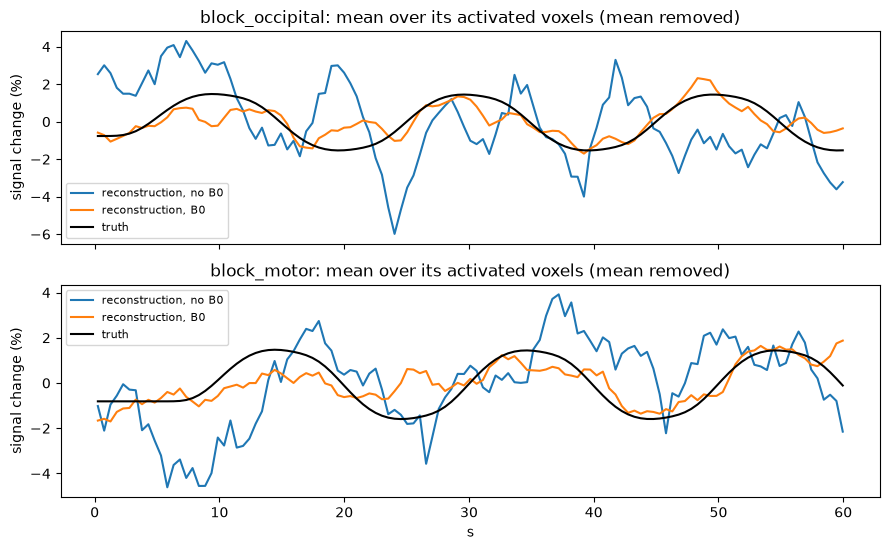

In [14]:
series = {}
for label, fn in RECONS.items():
    with h5py.File(fn) as f:
        X = np.abs(f["X_recon"][()])
    series[label] = [(scores[label]["alpha"] * X[roi] / x0[roi][:, None]).mean(axis=0)
                     for roi in rois]
t = (np.arange(X.shape[-1]) + 0.5) * volume_tr
fig, axes = plt.subplots(len(rois), 1, figsize=(9, 2.8 * len(rois)), sharex=True, squeeze=False)
for k, (ax, name) in enumerate(zip(axes[:, 0], names)):
    for label in RECONS:
        ax.plot(t, 100 * (series[label][k] - series[label][k].mean()),
                label=f"reconstruction, {label}")
    ax.plot(t, 100 * truth["amps"][k] * waves[k], "k", label="truth")
    ax.set_ylabel("signal change (%)")
    ax.set_title(f"{name}: mean over its activated voxels (mean removed)")
    ax.legend(fontsize=8)
axes[-1, 0].set_xlabel("s")
plt.tight_layout()
plt.show()

The scorer's panel for the B0-corrected reconstruction, once per region (slices
through that region, t-map of that region's regressor): the mean image against
the truth (note the signal lost above the sinuses, where the field varies
within a voxel), the temporal standard deviation, and the t-map. The slow
patterns outside the outlined regions are the simulated BOLD-like
physiological noise, on which this plain GLM is not calibrated.

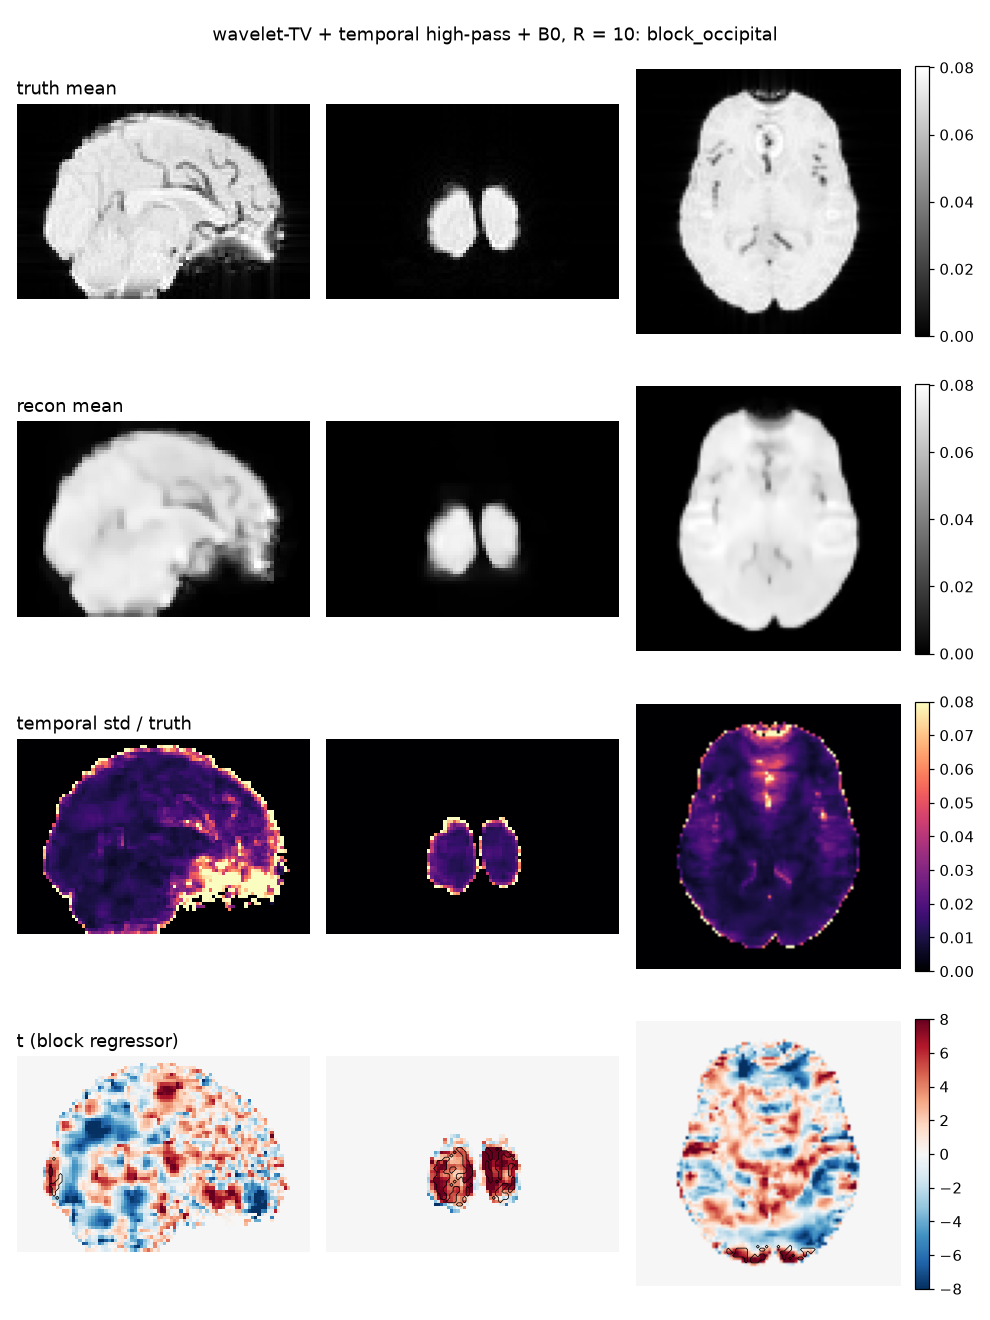

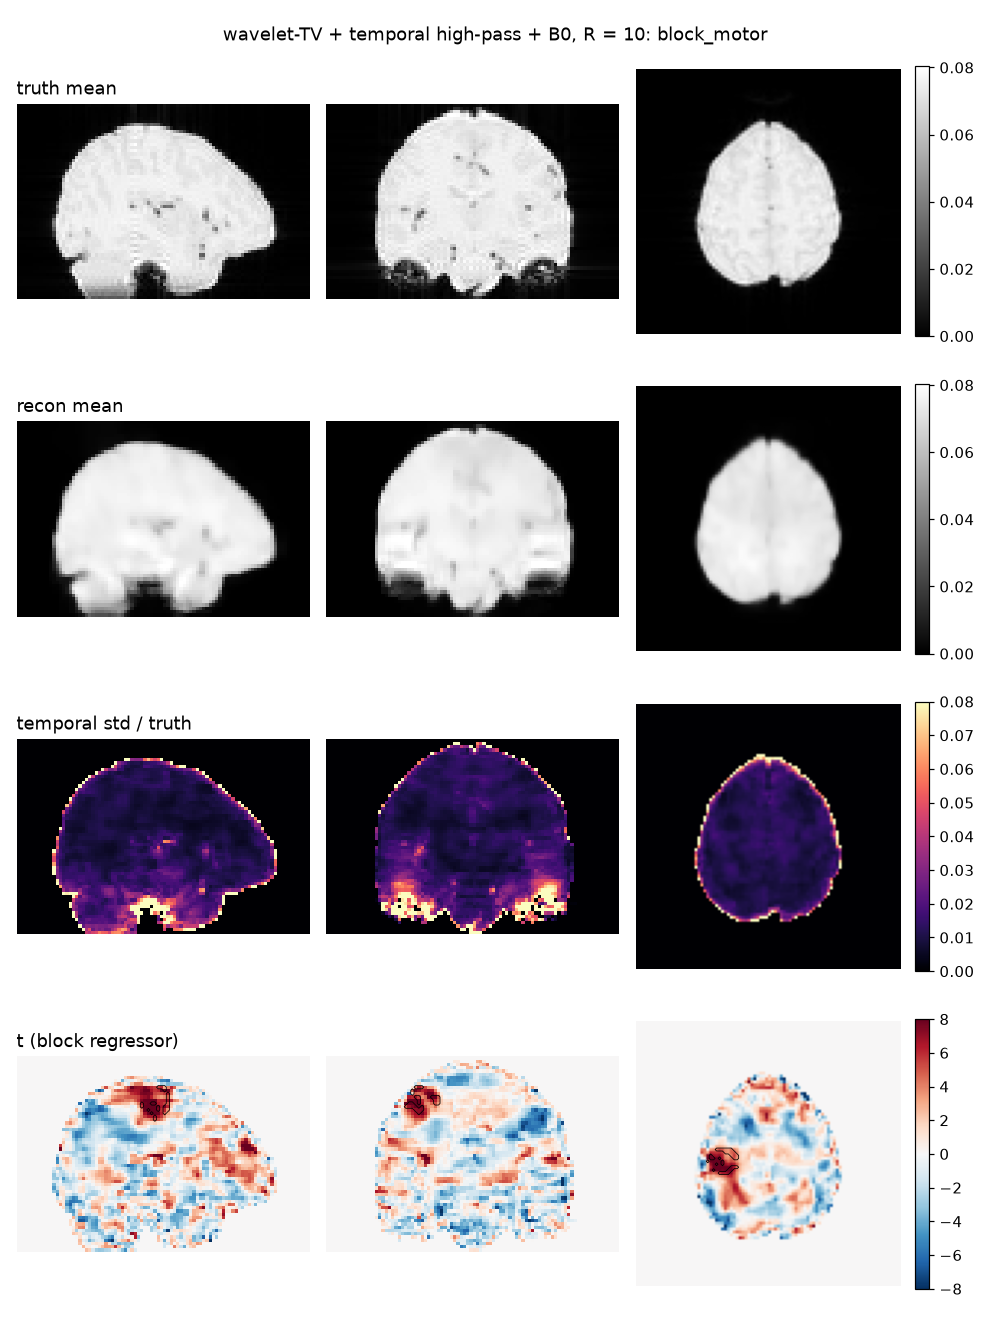

In [15]:
from IPython.display import Image, display  # noqa: E402

for k, name in enumerate(names):
    png = f"{OUT}/{NAME}_panel_{name}.png"
    testbed.panel(paths["truth"], RECONS["B0"], png,
                  f"wavelet-TV + temporal high-pass + B0, R = 10: {name}", roi=k)
    display(Image(png, width=650))

## Where to go from here

- **Switch effects off** to see what each costs: `SessionConfig(b0_scale=0)`,
  `noise=0`, `physio=None`, `activation=False`, `delay=0, oe_phase=(0, 0)`,
  `grid_factor=1`.
- **Another task**: `SessionConfig(activations=(...))` with one
  `simulate_fmri.session.Activation(region, block_on, block_off, onset,
  delta_r2s)` per region: `'occipital'` and `'motor'` exist on both phantoms.
- **Another protocol**: change `params.py` (`R`, `ETL`, `sampling_method`,
  `epi_trajectory`, resolution, `duration`) and rerun from the top.
- **Other reconstructions**: any `recon.sense` setting, with or without `--B0`,
  scored the same way.
- **The ideal mode** (`python -m simulate_fmri.ideal`) skips preprocessing:
  Cartesian samples, known coil maps, no field. Its forward model is the
  recon's own, which makes it the exact reference.
- **From the command line**: `python -m simulate_fmri.session`,
  `python -m preprocess.batch_preprocess`, `python -m recon.sense`,
  `python -m recon.testbed score` (see `README.md`).